# Plot carbonate species as function of pH/total CO$_2$

## 1) Plot carbonate species as alkalinity varies, with fixed DIC:

extracting pickled variable: name= Kh ; type= <class 'numpy.ndarray'> ; size= (1,)
extracting pickled variable: name= K1 ; type= <class 'numpy.ndarray'> ; size= (1,)
extracting pickled variable: name= K2 ; type= <class 'numpy.ndarray'> ; size= (1,)
extracting pickled variable: name= Kb ; type= <class 'numpy.ndarray'> ; size= (1,)
extracting pickled variable: name= Kw ; type= <class 'numpy.ndarray'> ; size= (1,)
extracting pickled variable: name= Ks ; type= <class 'numpy.ndarray'> ; size= (1,)
extracting pickled variable: name= Kf ; type= <class 'numpy.ndarray'> ; size= (1,)
extracting pickled variable: name= VpH ; type= <class 'numpy.ndarray'> ; size= (130,)
extracting pickled variable: name= Vhco3 ; type= <class 'numpy.ndarray'> ; size= (130,)
extracting pickled variable: name= Vco3 ; type= <class 'numpy.ndarray'> ; size= (130,)
extracting pickled variable: name= Vco2 ; type= <class 'numpy.ndarray'> ; size= (130,)
extracting pickled variable: name= Valk ; type= <class 'numpy.ndarray'>

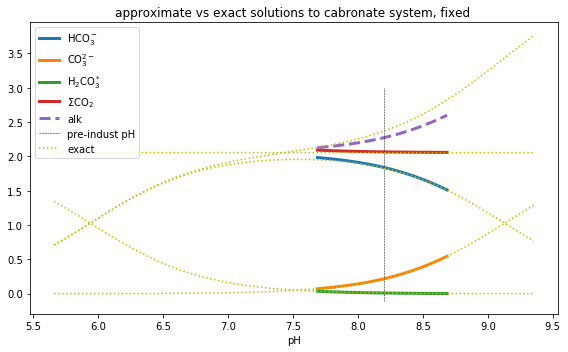

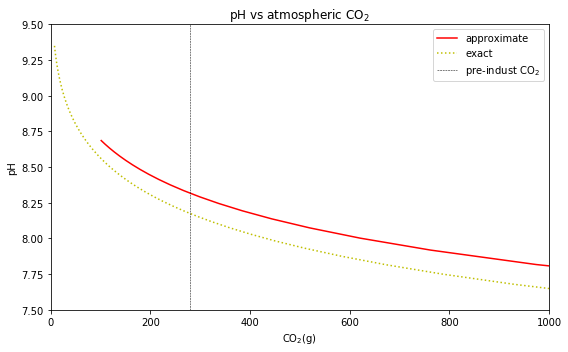

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import pickle

def solve_approximate_carbonate_system(dic,alk):
    C_T=dic
    hco3=2*C_T-alk
    co3=alk-C_T
    H=K2*(2*C_T-alk)/(alk-C_T)
    pH=-np.log10(H)
    co2=(K2/K1)*(2*C_T-alk)**2/(alk-C_T) # this is $H_2CO_3^*$
    pco2=(K2/K1*Kh)*(2*C_T-alk)**2/(alk-C_T)

    return pH,pco2,co2,hco3,co3


# load the PDI data from a pickle file to variables
with open('./Data/equilibrium_constants.pickle', 'rb') as file:
        d = pickle.load(file)
        # print information about each extracted variable:
        for key in list(d.keys()):
            print("extracting pickled variable: name=", key, "; type=",type(d[key]), "; size=", d[key].shape)
        globals().update(d)


# reference values for inputs:
dic=2000*1028e-6
alk0=2300*1028e-6
myrange=np.arange(0.9,1.1,0.01)
N=len(myrange)
# initialize array of output values:
VAalk=np.zeros(N)
VApH=np.zeros(N)
VApco2=np.zeros(N)
VAco2=np.zeros(N)
VAhco3=np.zeros(N)
VAco3=np.zeros(N)
i=-1
for alk in alk0*myrange:
    i=i+1
    pH,pco2,co2,hco3,co3 = solve_approximate_carbonate_system(alk=alk, dic=dic)
    VAalk[i]=alk
    VApH[i]=pH
    VApco2[i]=pco2
    VAco2[i]=co2
    VAhco3[i]=hco3
    VAco3[i]=co3
    #print(pH,pco2,fco2,co2,hco3,co3)

# plot calculated approximate solution fpor carbonate species:
plt.figure(1,figsize=(8,5))
VAtotCO2=VAhco3+VAco3+VAco2
plt.plot(VApH,VAhco3,label="HCO$_3^-$",lw=3)
plt.plot(VApH,VAco3,label="CO$_3^{2-}$",lw=3)
plt.plot(VApH,VAco2,label="H$_2$CO$_3^*$",lw=3)
plt.plot(VApH,VAtotCO2,label="$\Sigma$CO$_2$",lw=3)
plt.plot(VApH,VAalk,"--",label="alk",lw=3)
# mark preindustrial pH with a vertical line:
plt.plot([8.2,8.2],[-0.1,3.0],color="k",linewidth=0.5,linestyle="--",label="pre-indust pH")
plt.xlabel("pH")
plt.title("approximate vs exact solutions to cabronate system, fixed ")

# read exact solution from pickle file and plot it:
with open('./Data/fixed_DIC.pickle', 'rb') as file:
        d = pickle.load(file)
        # print information about each extracted variable:
        for key in list(d.keys()):
            print("extracting pickled variable: name=", key, "; type=",type(d[key]), "; size=", d[key].shape)
        globals().update(d)
VtotCO2=Vhco3+Vco3+Vco2
plt.plot(VpH,Vhco3,":y",label="exact")
plt.plot(VpH,Vco3,":y")
plt.plot(VpH,Vco2,":y")
plt.plot(VpH,VtotCO2,":y")
plt.plot(VpH,Valk,":y")
plt.legend(loc='upper left')
plt.tight_layout()

# plot pH vs co2(g):
plt.figure(2,figsize=(8,5))
plt.plot(VApco2*1000000,VApH,"-r",label='approximate')
plt.plot(Vpco2,VpH,":y",label='exact')
plt.ylabel('pH')
plt.xlabel('CO$_2$(g)')
plt.title("pH vs atmospheric CO$_2$")
# mark preindustrial CO2 with a vertical line:
plt.plot([280,280],[7.5,9.5],color="k",linewidth=0.5,linestyle="--",label="pre-indust CO$_2$")
plt.xlim(0,1000)
plt.ylim(7.5,9.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 2) Plot carbonate species as DIC varies, with fixed Alk:

extracting pickled variable: name= VpH ; type= <class 'numpy.ndarray'> ; size= (190,)
extracting pickled variable: name= Vhco3 ; type= <class 'numpy.ndarray'> ; size= (190,)
extracting pickled variable: name= Vco3 ; type= <class 'numpy.ndarray'> ; size= (190,)
extracting pickled variable: name= Vco2 ; type= <class 'numpy.ndarray'> ; size= (190,)
extracting pickled variable: name= Valk ; type= <class 'numpy.ndarray'> ; size= (190,)
extracting pickled variable: name= Vpco2 ; type= <class 'numpy.ndarray'> ; size= (190,)


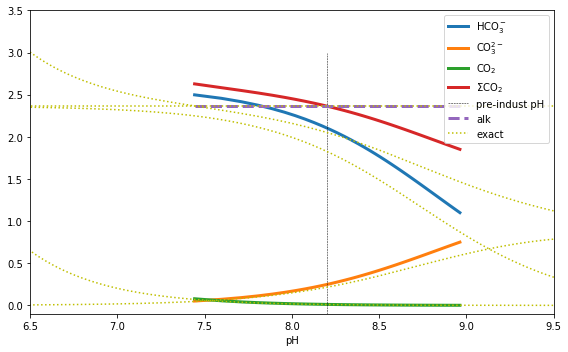

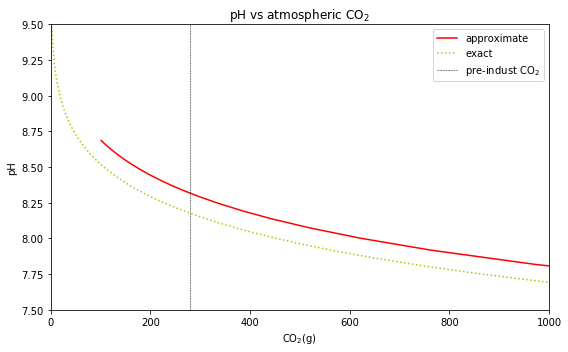

In [10]:
# Plot carbonate species as DIC varies:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# reference values for inputs:
dic0=2000*1028e-6
alk0=2300*1028e-6
myrange=np.arange(0.9,1.25,0.01)
N=len(myrange)
# initialize array of output values:
Valk=np.zeros(N)
VpH=np.zeros(N)
Vpco2=np.zeros(N)
Vco2=np.zeros(N)
Vhco3=np.zeros(N)
Vco3=np.zeros(N)
i=-1
for dic in dic0*myrange:
    i=i+1
    pH,pco2,co2,hco3,co3 = solve_approximate_carbonate_system(alk=alk, dic=dic)
    Valk[i]=alk0
    VpH[i]=pH
    Vpco2[i]=pco2
    Vco2[i]=co2
    Vhco3[i]=hco3
    Vco3[i]=co3
    #print(pH,pco2,fco2,co2,hco3,co3)

# plot calculated approximate solution:
plt.figure(1,figsize=(8,5))
VtotCO2=Vhco3+Vco3+Vco2
plt.plot(VpH,Vhco3,label="HCO$_3^-$",lw=3)
plt.plot(VpH,Vco3,label="CO$_3^{2-}$",lw=3)
plt.plot(VpH,Vco2,label="CO$_2$",lw=3)
plt.plot(VpH,VtotCO2,label="$\Sigma$CO$_2$",lw=3)
plt.plot([8.2,8.2],[-0.1,3.0],color="k",linewidth=0.5,linestyle="--",label="pre-indust pH")
plt.plot(VpH,Valk,"--",label="alk",lw=3)
plt.xlabel("pH")
plt.legend()

# read exact solution from pickle file and plot it as dotted yellow line:
with open('./Data/fixed_Alk.pickle', 'rb') as file:
        d = pickle.load(file)
        # print information about each extracted variable:
        for key in list(d.keys()):
            print("extracting pickled variable: name=", key, "; type=",type(d[key]), "; size=", d[key].shape)
        globals().update(d)
VtotCO2=Vhco3+Vco3+Vco2
plt.plot(VpH,Vhco3,":y",label="exact")
plt.plot(VpH,Vco3,":y")
plt.plot(VpH,Vco2,":y")
plt.plot(VpH,VtotCO2,":y")
plt.plot(VpH,Valk,":y")
plt.xlim(6.5,9.5)
plt.ylim(-0.1,3.5)
plt.legend()
plt.tight_layout()

# plot pH vs co2(g):
plt.figure(2,figsize=(8,5))
plt.plot(VApco2*1000000,VApH,"-r",label='approximate')
plt.plot(Vpco2,VpH,":y",label='exact')
plt.ylabel('pH')
plt.xlabel('CO$_2$(g)')
plt.title("pH vs atmospheric CO$_2$")
plt.xlim(0,1000)
# mark preindustrial CO2 with a vertical line:
plt.plot([280,280],[7.5,9.5],color="k",linewidth=0.5,linestyle="--",label="pre-indust CO$_2$")
plt.legend()
plt.ylim(7.5,9.5)
plt.tight_layout()
